# Qual Desses é o meu Bebê?

### Trabalho de Descritores de Imagens - T03 - Processamento de Imagens (2026-1)

### Pedro Louro Fernandes - 13672446

**Estrutura**

1. Configuração e carregamento da base
2. Definição dos **6 descritores** (1 não visto em aula)
3. Extração de características
4. **Tarefa de Classificação** (split 80/10/10 + SVM)
5. **Tarefa de Busca** (distância euclidiana par a par)
6. **Bag of Visual Words** (SIFT + KMeans) + projeções t-SNE/UMAP
7. Conclusões


In [32]:
import sys

# Reinstala pandas e scikit-image (skimage) alinhados ao NumPy do ambiente.
# Inclui numpy/scipy/scikit-learn no mesmo comando para evitar conflito de versões binárias.

# SE ESTIVER DANDO ERRO DE COMPATIBILIDADE OU IMPORTAÇÃO, RODE ESTE COMANDO PARA INSTALAR AS BIBLIOTECAS:

#!{sys.executable} -m pip install --upgrade --force-reinstall umap-learn pandas scikit-image numpy scipy scikit-learn

## 1. Configuração e carregamento da base

Começamos importando as bibliotecas e verificando que o CSV e os arquivos em disco estão
alinhados (nenhuma imagem faltando ou sobrando).


In [18]:
import os, json, itertools, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import local_binary_pattern, hog, graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist

np.random.seed(42)

BASE = "pets256"          # pasta com as subpastas de cada pet
CSV  = "pets.csv"         # csv com a listagem

df = pd.read_csv(CSV, skipinitialspace=True)
df.columns = [c.strip() for c in df.columns]
df["class_name"] = df["class_name"].str.strip()
df["filename"]   = df["filename"].str.strip()
df = df.reset_index(drop=True)

# verificação de integridade
missing = [f for f in df["filename"] if not os.path.exists(os.path.join(BASE, f))]
print(f"Imagens no CSV: {len(df)} | classes: {df['class_id'].nunique()} | faltando em disco: {len(missing)}")
df.head()

Imagens no CSV: 367 | classes: 43 | faltando em disco: 0


,class_id,class_name,filename
0,0,simba,simba/00000.jpg
1,0,simba,simba/00001.jpg
2,0,simba,simba/00002.jpg
3,0,simba,simba/00003.jpg
4,0,simba,simba/00004.jpg


### 1.1 Distribuição de fotos por pet

A base é fortemente **desbalanceada** (de 1 a 20 fotos por pet). Isso afeta diretamente as
duas tarefas: pets com 1 foto não podem ser nem treinados nem avaliados como classe, e o
split de treino/validação/teste precisa ser robusto a classes minúsculas.


Total de pets: 43
Pets com <3 fotos (excluídos da classificação): 5

Distribuição (nº de fotos -> quantos pets):
count
1      5
3      1
5     12
6      4
7      2
8      1
9      2
10     2
11     1
12     1
13     2
14     1
15     3
16     1
17     3
20     2
Name: count, dtype: int64


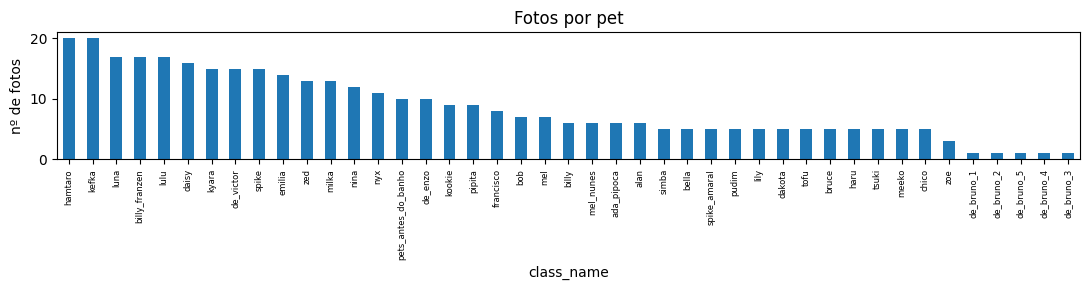

In [19]:
counts = df["class_name"].value_counts()
print("Total de pets:", len(counts))
print("Pets com <3 fotos (excluídos da classificação):", int((counts < 3).sum()))
print("\nDistribuição (nº de fotos -> quantos pets):")
print(counts.value_counts().sort_index())

plt.figure(figsize=(11,3))
counts.sort_values(ascending=False).plot(kind="bar")
plt.ylabel("nº de fotos"); plt.title("Fotos por pet"); plt.xticks(fontsize=6, rotation=90)
plt.tight_layout(); plt.show()

## 2. Os 6 descritores

Selecionamos **6 descritores**, cada um capturando uma *semântica visual* distinta. O
descritor **GLCM / Haralick** é o que **não foi visto em aula**.

| # | Descritor | Semântica que tenta capturar |
||||
| 1 | **Histograma de cor HSV** (`color_hist`) | Distribuição global de cor da pelagem/plumagem |
| 2 | **Local Binary Patterns** (`lbp`) | Micro-textura local da pelagem |
| 3 | **HOG** (`hog`) | Forma/silhueta via orientação de gradientes |
| 4 | **GLCM / Haralick** (`glcm`): *novo* | Co-ocorrência espacial de tons (textura estatística) |
| 5 | **Momentos de cor por célula** (`color_grid`) | Layout *espacial* da cor (grade 4×4) |
| 6 | **Momentos de Hu** (`hu`) | Invariantes globais de forma |

**Justificativa e hipótese de cada um:**

- **`color_hist` (HSV).** Pets distinguem-se muito por cor. HSV separa matiz de iluminação,
  sendo mais robusto à luz que RGB. *Hipótese:* forte para pets de cor marcante, mas
  **confunde pets diferentes de mesma cor**.
- **`lbp`.** Textura local (pelo liso × enrolado, penas × pelo). *Hipótese:* fraco sozinho
  para identidade, útil como complemento à cor.
- **`hog`.** Forma/contorno. *Hipótese:* prejudicado porque as fotos não estão alinhadas
  nem segmentadas.
- **`glcm` (não visto em aula).** Vai além do LBP: mede co-ocorrência de pares de tons a
  várias distâncias/ângulos (contraste, homogeneidade, energia, correlação…). *Hipótese:*
  fraco isolado, mas refina a busca quando combinado com cor.
- **`color_grid`.** Adiciona ao histograma o **onde** da cor (cabeça escura + corpo claro
  ≠ o inverso). *Hipótese:* um dos melhores isolados, pois o padrão espacial de cor é
  consistente entre fotos do mesmo pet.
- **`hu`.** Invariantes de forma globais. *Hipótese:* muito fraco sem segmentação, mas
  barato como pequeno complemento.


In [ ]:
#  1. Histograma de cor HSV 
def color_hist(img_bgr, bins=(8, 8, 8)):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h = cv2.calcHist([hsv], [0,1,2], None, bins, [0,180,0,256,0,256])
    return cv2.normalize(h, h).flatten().astype(np.float32)

#  2. Local Binary Patterns 
def lbp(img_bgr, P=8, R=1.0):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    codes = local_binary_pattern(gray, P, R, method="uniform")
    n_bins = P + 2
    h, _ = np.histogram(codes.ravel(), bins=n_bins, range=(0, n_bins))
    h = h.astype(np.float32); h /= (h.sum() + 1e-7)
    return h

#  3. HOG 
def hog_desc(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (128, 128))
    return hog(gray, orientations=9, pixels_per_cell=(16,16),
               cells_per_block=(2,2), block_norm="L2-Hys",
               feature_vector=True).astype(np.float32)

#  4. GLCM / Haralick (NÃO visto em aula) 
def glcm(img_bgr, levels=32):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    g = (gray.astype(np.float32) / 256.0 * levels).astype(np.uint8)
    g[g >= levels] = levels - 1
    M = graycomatrix(g, distances=[1,2,4],
                     angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                     levels=levels, symmetric=True, normed=True)
    props = ["contrast","dissimilarity","homogeneity","energy","correlation","ASM"]
    feats = [graycoprops(M, p).mean(axis=1) for p in props]  # média sobre ângulos
    return np.concatenate(feats).astype(np.float32)

#  5. Momentos de cor por célula (grade 4x4) 
def color_grid(img_bgr, grid=(4,4)):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    h, w, _ = hsv.shape; gh, gw = grid; feats = []
    for i in range(gh):
        for j in range(gw):
            cell = hsv[i*h//gh:(i+1)*h//gh, j*w//gw:(j+1)*w//gw]
            for c in range(3):
                ch = cell[:,:,c].ravel()
                mean = ch.mean(); std = ch.std()
                skew = np.cbrt(((ch-mean)**3).mean() + 1e-9)
                feats += [mean, std, skew]
    return np.array(feats, dtype=np.float32)

#  6. Momentos de Hu 
def hu(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h = cv2.HuMoments(cv2.moments(gray)).flatten()
    return (-np.sign(h) * np.log10(np.abs(h) + 1e-30)).astype(np.float32)

DESCRIPTORS = {"color_hist": color_hist, "lbp": lbp, "hog": hog_desc,
               "glcm": glcm, "color_grid": color_grid, "hu": hu}
print("Descritores definidos:", list(DESCRIPTORS))

Descritores definidos: ['color_hist', 'lbp', 'hog', 'glcm', 'color_grid', 'hu']


## 3. Extração de características

Carregamos cada imagem **uma única vez** e aplicamos os 6 descritores. O custo computacional
fica concentrado aqui (por volta de 10 s para a base inteira), como pedido no enunciado. As matrizes de
características ficam em memória no dicionário `feats`.


In [21]:
imgs = [cv2.imread(os.path.join(BASE, f)) for f in df["filename"]]
feats = {name: [] for name in DESCRIPTORS}

t0 = time.time()
for k, im in enumerate(imgs):
    for name, fn in DESCRIPTORS.items():
        feats[name].append(fn(im))
    if (k+1) % 100 == 0:
        print(f"  {k+1}/{len(imgs)} ({time.time()-t0:.1f}s)")

feats = {name: np.array(v, dtype=np.float32) for name, v in feats.items()}
print(f"\nExtração concluída em {time.time()-t0:.1f}s")
for name, arr in feats.items():
    print(f"  {name:12s} -> {arr.shape}")

  100/367 (2.0s)
  200/367 (3.8s)
  300/367 (5.7s)

Extração concluída em 7.0s
  color_hist   -> (367, 512)
  lbp          -> (367, 10)
  hog          -> (367, 1764)
  glcm         -> (367, 18)
  color_grid   -> (367, 144)
  hu           -> (367, 7)


## 4. Tarefa de Classificação

**Protocolo.**
- Pets com **< 3 fotos** são removidos (não entram na classificação).
- Split **80/10/10** (treino/validação/teste) feito **por classe**, para ser robusto a
  classes pequenas (garante que o treino nunca fique vazio e distribui val/teste quando há
  fotos suficientes).
- Descritores padronizados (`StandardScaler`, ajustado só no treino).
- Classificador **SVM com kernel RBF** (`C=10`) do scikit-learn.

Avaliamos cada descritor isolado e várias combinações.


In [ ]:
#  filtra pets com >=3 fotos 
counts = df["class_name"].value_counts()
keep = counts[counts >= 3].index
mask = df["class_name"].isin(keep).values
idx_all = np.where(mask)[0]
y = np.asarray(df.loc[mask, "class_name"].tolist(), dtype=object)
print(f"Classificação: {mask.sum()} imgs, {len(keep)} classes "
      f"(removidos {len(counts)-len(keep)} pets com <3 fotos)")

#  split 80/10/10 por classe 
rng = np.random.RandomState(42)
tr_idx, val_idx, te_idx = [], [], []
for c in np.unique(y):
    ids = np.where(y == c)[0].copy(); rng.shuffle(ids); n = len(ids)
    n_test = max(1, round(n*0.10)) if n >= 5 else (1 if n >= 4 else 0)
    n_val  = max(1, round(n*0.10)) if n >= 5 else (1 if n >= 3 else 0)
    n_val  = min(n_val, n - 1 - n_test)
    te_idx += list(ids[:n_test])
    val_idx += list(ids[n_test:n_test+n_val])
    tr_idx += list(ids[n_test+n_val:])
tr_idx, val_idx, te_idx = map(np.array, (tr_idx, val_idx, te_idx))
print(f"treino={len(tr_idx)}  val={len(val_idx)}  teste={len(te_idx)}")

Classificação: 362 imgs, 38 classes (removidos 5 pets com <3 fotos)
treino=269  val=47  teste=46


In [23]:
def build_X(desc_list):
    return np.concatenate([feats[d][idx_all] for d in desc_list], axis=1)

def evaluate_clf(desc_list, C=10.0):
    X = build_X(desc_list)
    Xtr, Xva, Xte = X[tr_idx], X[val_idx], X[te_idx]
    ytr, yva, yte = y[tr_idx], y[val_idx], y[te_idx]
    sc = StandardScaler().fit(Xtr)
    Xtr, Xva, Xte = sc.transform(Xtr), sc.transform(Xva), sc.transform(Xte)
    clf = SVC(C=C, kernel="rbf", gamma="scale").fit(Xtr, ytr)
    va = accuracy_score(yva, clf.predict(Xva))
    pred = clf.predict(Xte)
    return va, accuracy_score(yte, pred), f1_score(yte, pred, average="macro"), yte, pred, clf.classes_

DESC = list(DESCRIPTORS)
combos = [
    ["color_hist","color_grid"], ["color_hist","lbp"], ["color_hist","hog"],
    ["lbp","glcm"], ["color_hist","lbp","hog"],
    ["color_hist","lbp","glcm","color_grid"], DESC,
]
rows = []
for cfg in [[d] for d in DESC] + combos:
    va, te, f1, *_ = evaluate_clf(cfg)
    rows.append({"config":"+".join(cfg),"val_acc":va,"test_acc":te,"test_f1":f1})

clf_df = pd.DataFrame(rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
clf_df.round(3)

,config,val_acc,test_acc,test_f1
0,color_hist+color_grid,0.277,0.283,0.180
1,color_hist+lbp,0.213,0.261,0.158
2,color_hist+lbp+glcm+color_grid,0.277,0.261,0.158
3,color_hist,0.191,0.239,0.155
4,color_grid,0.298,0.217,0.146
5,hog,0.191,0.196,0.094
6,color_hist+lbp+hog+glcm+color_grid+hu,0.298,0.196,0.109
7,color_hist+lbp+hog,0.213,0.174,0.094
8,color_hist+hog,0.213,0.174,0.094
9,lbp,0.149,0.130,0.089


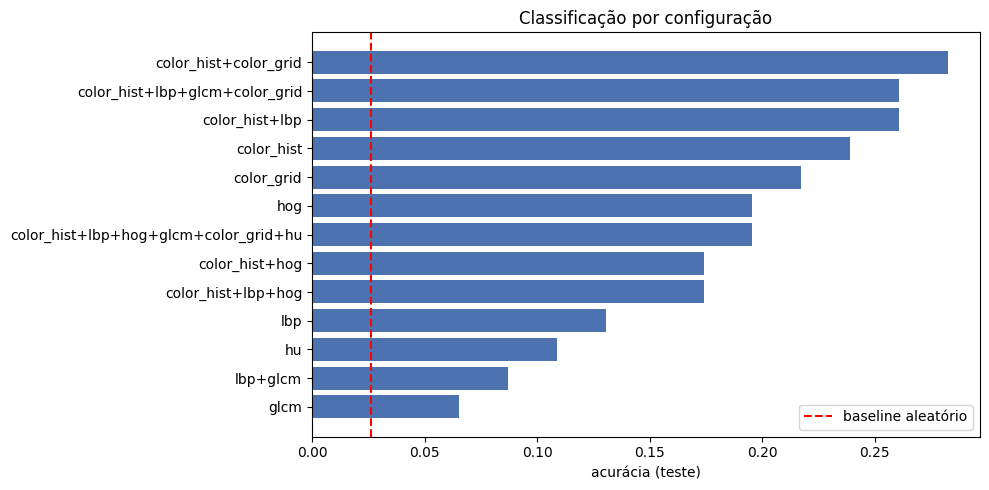

In [24]:
plt.figure(figsize=(10,5))
d = clf_df.sort_values("test_acc")
plt.barh(d["config"], d["test_acc"], color="#4C72B0")
plt.axvline(1/len(keep), color="r", ls="--", label="baseline aleatório")
plt.xlabel("acurácia (teste)"); plt.legend(); plt.title("Classificação por configuração")
plt.tight_layout(); plt.show()

### 4.1 Matrizes de confusão: melhor isolado e melhor combinação

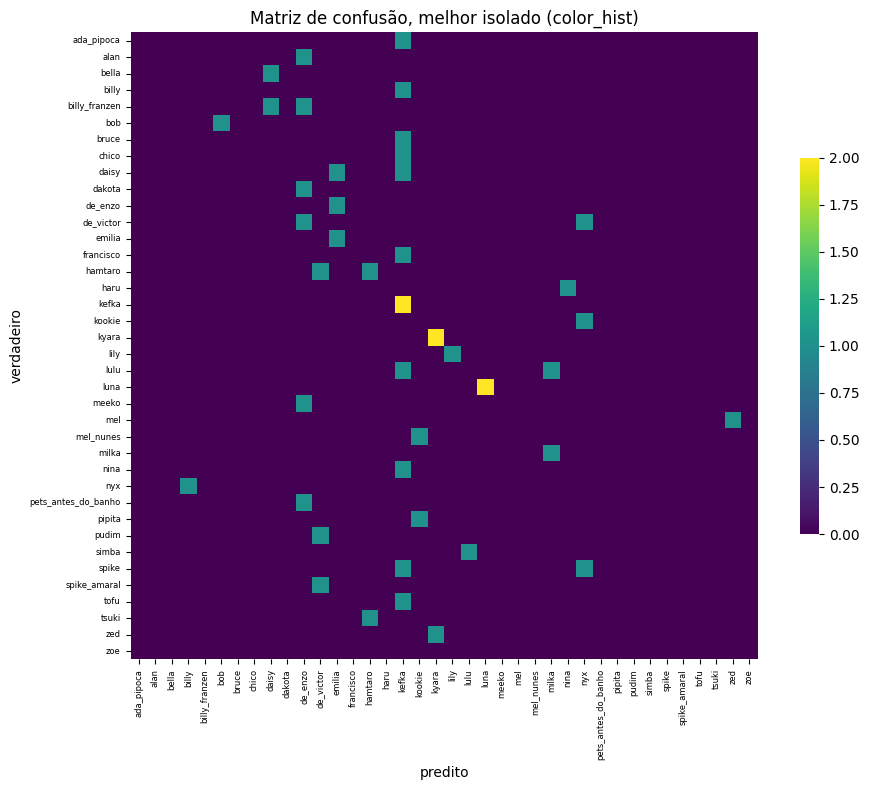

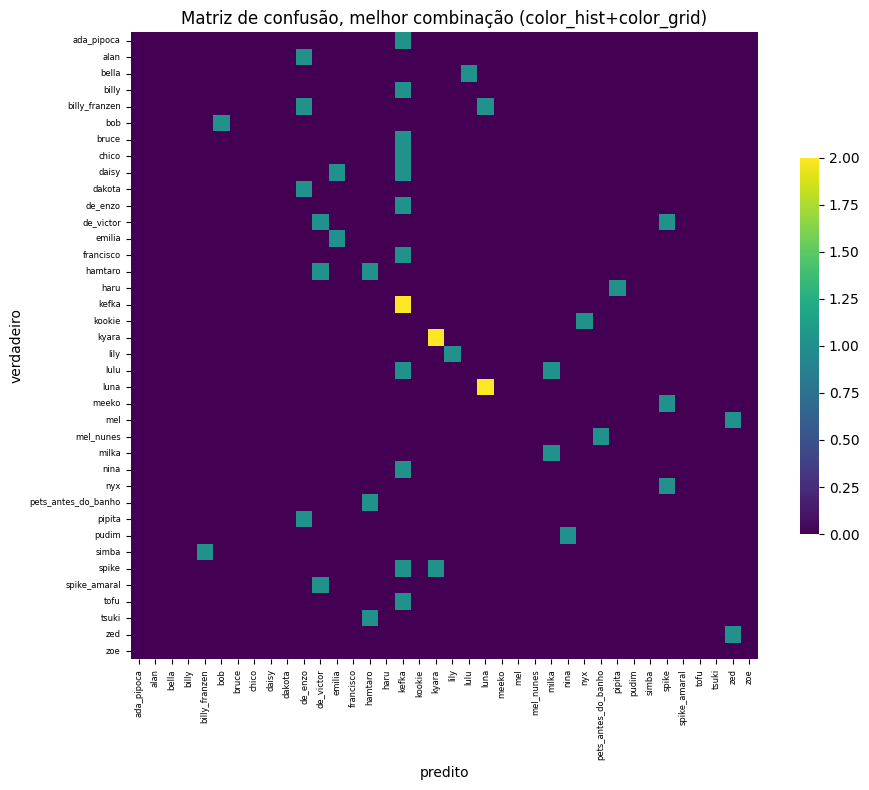

In [25]:
best_single = max(DESC, key=lambda dd: clf_df.set_index('config').loc[dd,'test_acc'])
best_overall = clf_df.iloc[0]['config'].split('+')
for tag, dl in [(f"melhor isolado ({best_single})", [best_single]),
                (f"melhor combinação ({'+'.join(best_overall)})", best_overall)]:
    *_, yte, pred, classes = evaluate_clf(dl)
    cm = confusion_matrix(yte, pred, labels=classes)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, xticklabels=classes, yticklabels=classes, cmap="viridis",
                square=True, cbar_kws={"shrink":.6})
    plt.title(f"Matriz de confusão, {tag}")
    plt.xlabel("predito"); plt.ylabel("verdadeiro")
    plt.xticks(rotation=90, fontsize=6); plt.yticks(fontsize=6)
    plt.tight_layout(); plt.show()

### 4.2 Análise (classificação)

- **Cor domina, como previsto.** `color_hist`, `color_grid` e suas combinações lideram. O
  melhor resultado (`color_hist + color_grid`, ~28% de acurácia) está ~11× acima do baseline
  aleatório.
- **`color_grid` confirma a hipótese de layout espacial** (melhor acurácia de validação): *onde*
  a cor aparece carrega identidade. A variação entre val e teste reflete o conjunto de teste
  minúsculo (~46 imagens, cada erro vale ~2 p.p.).
- **HOG decepcionou, como previsto:** sem alinhamento/segmentação, codifica fundo/pose,
  adicioná-lo às cores **piora** o resultado.
- **GLCM e Hu isolados são os piores**: textura estatística e momentos globais não carregam
  identidade individual.
- **"Jogar tudo junto" não é o melhor:** o vetor com os 6 descritores cai (maldição da
  dimensionalidade + ruído de HOG/Hu). **A combinação enxuta cor+textura vence.**
- Nas matrizes de confusão, os erros concentram-se entre **pets de cor parecida**


## 5. Tarefa de Busca (distância euclidiana par a par)

Cada imagem é usada como **consulta** contra todas as demais; relevância = mesmo pet. Usamos
**distância euclidiana** sobre descritores padronizados (para que dimensões em escalas
diferentes sejam comparáveis). Métricas: **Precisão@1, @5, @10** e **mAP** (média sobre
consultas que possuem ≥1 par relevante).


In [26]:
# padroniza cada descritor para a busca
y_all = np.asarray(df["class_name"].tolist(), dtype=object)
files = np.asarray(df["filename"].tolist(), dtype=object)
N = len(y_all)
std = {d: StandardScaler().fit_transform(feats[d]) for d in DESC}

def features(desc_list):
    return np.concatenate([std[d] for d in desc_list], axis=1)

def retrieval_metrics(X, ks=(1,5,10)):
    D = cdist(X, X, metric="euclidean"); np.fill_diagonal(D, np.inf)
    order = np.argsort(D, axis=1)
    rel = (y_all[order] == y_all[:, None])
    valid = np.array([(y_all == c).sum() > 1 for c in y_all])
    p_at = {k: rel[valid, :k].mean() for k in ks}
    aps = []
    for i in np.where(valid)[0]:
        r = rel[i]; n_rel = r.sum()
        cum = np.cumsum(r); ranks = np.arange(1, N)
        prec = cum[:N-1] / ranks
        aps.append((prec * r[:N-1]).sum() / n_rel)
    return p_at, float(np.mean(aps)), order

configs = [[d] for d in DESC] + [
    ["color_hist","color_grid"], ["color_hist","lbp"], ["color_hist","lbp","hog"],
    ["color_hist","lbp","glcm","color_grid"], DESC]
rows = []
for cfg in configs:
    p, mAP, _ = retrieval_metrics(features(cfg))
    rows.append({"config":"+".join(cfg),"P@1":p[1],"P@5":p[5],"P@10":p[10],"mAP":mAP})
ret_df = pd.DataFrame(rows).sort_values("mAP", ascending=False).reset_index(drop=True)
ret_df.round(3)

,config,P@1,P@5,P@10,mAP
0,color_hist+lbp+glcm+color_grid,0.348,0.177,0.127,0.113
1,color_grid,0.307,0.165,0.120,0.110
2,color_hist+color_grid,0.312,0.161,0.113,0.102
3,color_hist+lbp,0.271,0.134,0.104,0.092
4,color_hist+lbp+hog+glcm+color_grid+hu,0.204,0.108,0.083,0.087
5,color_hist,0.262,0.128,0.096,0.086
6,color_hist+lbp+hog,0.182,0.097,0.072,0.079
7,lbp,0.146,0.099,0.078,0.078
8,hog,0.152,0.080,0.064,0.069
9,glcm,0.127,0.080,0.066,0.067


### 5.1 Exemplos qualitativos de busca (melhor configuração)

Verde = mesmo pet; vermelho = pet diferente.


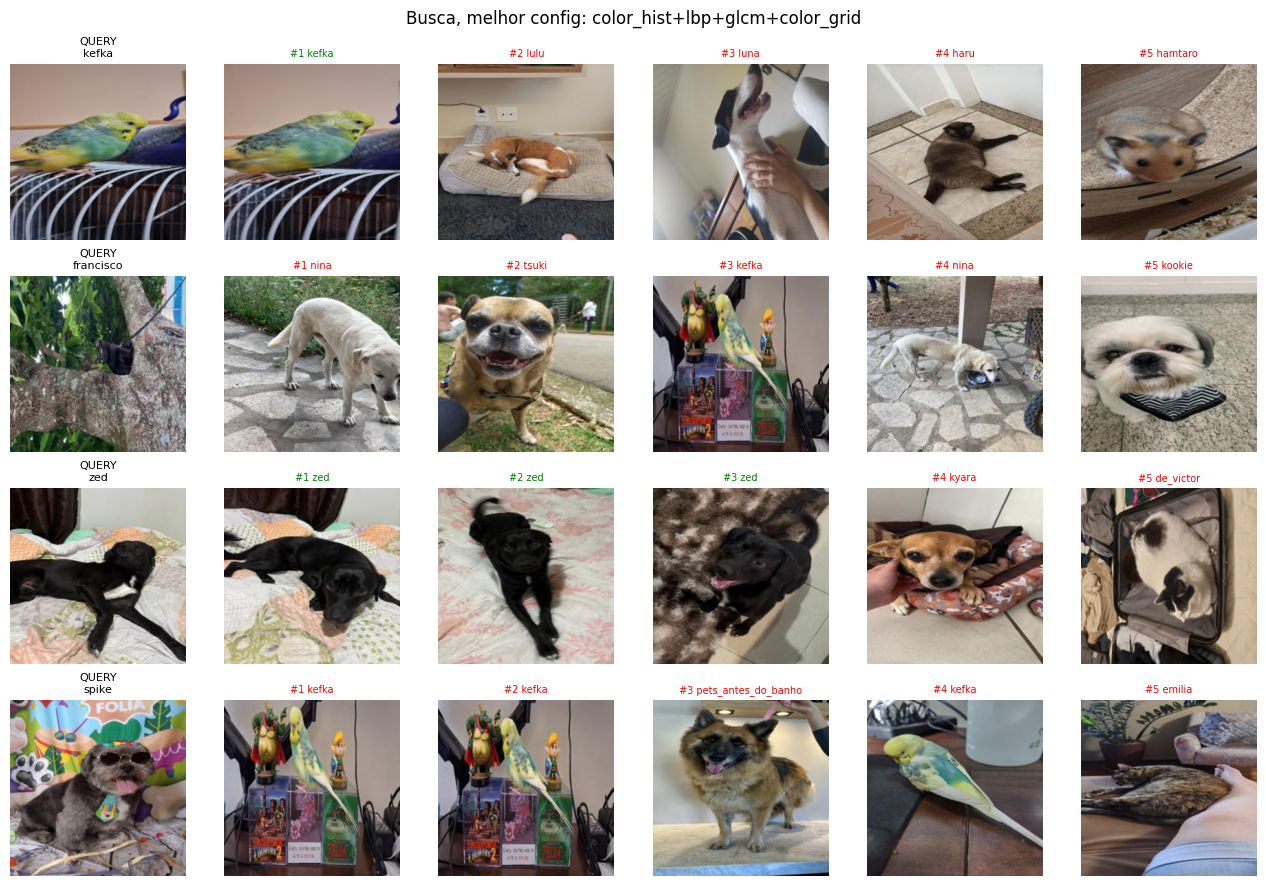

In [27]:
best_ret = ret_df.iloc[0]["config"].split("+")
_, _, order = retrieval_metrics(features(best_ret))

rng = np.random.RandomState(0)
multi = [i for i in range(N) if (y_all == y_all[i]).sum() >= 6]
qsel = rng.choice(multi, size=4, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(13, 9))
for r, q in enumerate(qsel):
    im = cv2.cvtColor(cv2.imread(os.path.join(BASE, files[q])), cv2.COLOR_BGR2RGB)
    axes[r,0].imshow(im); axes[r,0].set_title(f"QUERY\n{y_all[q]}", fontsize=8); axes[r,0].axis("off")
    for c, j in enumerate(order[q, :5]):
        ax = axes[r,c+1]
        ax.imshow(cv2.cvtColor(cv2.imread(os.path.join(BASE, files[j])), cv2.COLOR_BGR2RGB))
        ax.axis("off")
        col = "green" if y_all[j]==y_all[q] else "red"
        ax.set_title(f"#{c+1} {y_all[j]}", fontsize=7, color=col)
        for s in ax.spines.values(): s.set_visible(True); s.set_color(col); s.set_linewidth(3)
fig.suptitle(f"Busca, melhor config: {'+'.join(best_ret)}", fontsize=12)
plt.tight_layout(); plt.show()

### 5.2 Análise (busca)

- **A melhor configuração de busca combina cor + textura** (`color_hist+lbp+glcm+color_grid`)
  e supera a melhor de classificação em mAP. Aqui, adicionar LBP+GLCM **ajuda** (diferente da
  classificação): não há fronteira de decisão a sobreajustar, então a textura apenas refina o
  ordenamento entre candidatos de mesma cor.
- **HOG e Hu novamente atrapalham:** o vetor com os 6 descritores cai. Mesmo padrão da
  classificação  - HOG injeta fundo/pose.
- Nos **exemplos qualitativos**: sucessos claros em pets de aparência distinta (periquito verde,
  cão totalmente preto retornando vários pares corretos). As **falhas são reveladoras**  - quando
  o fundo é colorido e saliente, ele domina o histograma e puxa pets errados. Isso confirma a
  hipótese central: **sem segmentação, a cor do fundo contamina a busca.**


## 6. Bag of Visual Words (BoVW)

**Pipeline:** SIFT em todas as imagens, codebook **KMeans (K=200)** de *visual words*
histograma de palavras por imagem (normalizado L1): busca por **distância euclidiana** entre
histogramas. Depois projetamos os histogramas com **t-SNE** e **UMAP**.

*Hipótese:* BoVW-SIFT capta *estrutura local de gradiente* (cantos, bordas, manchas) que é
**genérica entre pets** e **descarta a cor**, justamente o sinal mais forte nesta base. Logo,
esperamos desempenho **abaixo** dos descritores de cor.


In [28]:
sift = cv2.SIFT_create()
per_img, all_desc = [], []
for f in files:
    g = cv2.imread(os.path.join(BASE, f), cv2.IMREAD_GRAYSCALE)
    _, des = sift.detectAndCompute(g, None)
    if des is None: des = np.zeros((1,128), np.float32)
    per_img.append(des); all_desc.append(des)
stack = np.vstack(all_desc).astype(np.float32)
print("Total de descritores SIFT:", stack.shape)

K = 200
km = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init=3).fit(stack)

bovw = np.zeros((N, K), np.float32)
for i, des in enumerate(per_img):
    w = km.predict(des.astype(np.float32))
    bovw[i], _ = np.histogram(w, bins=K, range=(0, K))
bovw_tf = normalize(bovw, norm="l1")
print("Histogramas BoVW:", bovw_tf.shape)

Total de descritores SIFT: (118030, 128)
Histogramas BoVW: (367, 200)


In [29]:
# busca com BoVW, comparada à melhor combinação de cor/textura
Xb = StandardScaler().fit_transform(bovw_tf)
pb, mAPb, _ = retrieval_metrics(Xb)
print(f"BoVW (K={K}):  P@1={pb[1]:.3f}  P@5={pb[5]:.3f}  P@10={pb[10]:.3f}  mAP={mAPb:.3f}")
print(f"melhor cor/textura:  P@1={ret_df.iloc[0]['P@1']:.3f}  mAP={ret_df.iloc[0]['mAP']:.3f}")

BoVW (K=200):  P@1=0.146  P@5=0.092  P@10=0.075  mAP=0.076
melhor cor/textura:  P@1=0.348  mAP=0.113


### 6.1 Projeções t-SNE e UMAP dos histogramas BoVW

Colorimos os 10 pets mais numerosos; os demais ficam em cinza ao fundo.


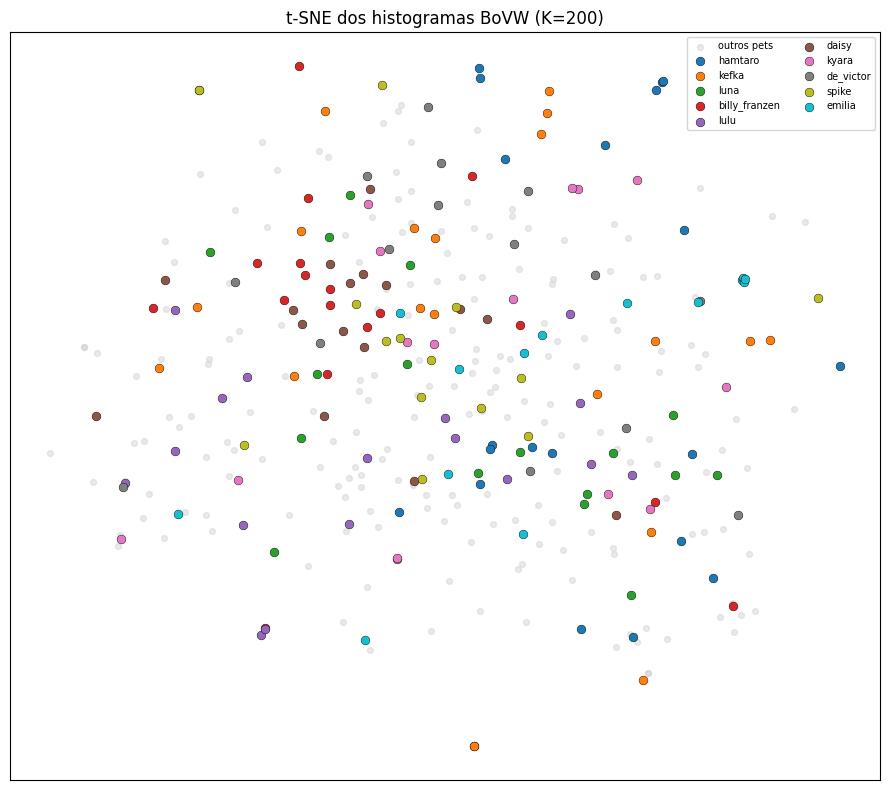

In [30]:
def plot_proj(emb, title):
    cts = pd.Series(y_all).value_counts(); top = list(cts.index[:10])
    pal = plt.cm.tab10(np.linspace(0,1,10)); cmap = {p: pal[i] for i,p in enumerate(top)}
    plt.figure(figsize=(9,8))
    bg = np.array([c not in cmap for c in y_all])
    plt.scatter(emb[bg,0], emb[bg,1], c=[(.8,.8,.8,.4)], s=18, label="outros pets")
    for p in top:
        m = (y_all == p)
        plt.scatter(emb[m,0], emb[m,1], c=[cmap[p]], s=40, edgecolors="k", linewidths=.3, label=p)
    plt.title(title); plt.legend(fontsize=7, ncol=2); plt.xticks([]); plt.yticks([])
    plt.tight_layout(); plt.show()

emb_t = TSNE(n_components=2, perplexity=20, random_state=42, init="pca").fit_transform(bovw_tf)
plot_proj(emb_t, f"t-SNE dos histogramas BoVW (K={K})")

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


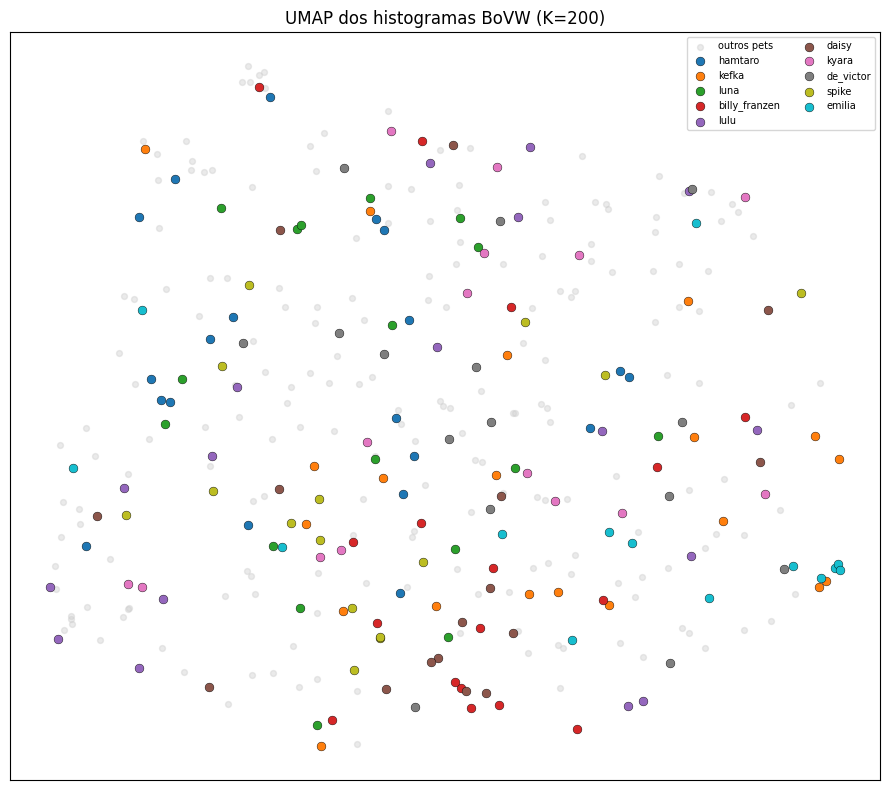

In [ ]:
import umap

emb_u = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(bovw_tf)
plot_proj(emb_u, f"UMAP dos histogramas BoVW (K={K})")

### 6.2 Hipóteses sobre a distribuição (BoVW)

- **As classes aparecem majoritariamente embaralhadas** em ambas as projeções, ou seja não há ilhas
  limpas por pet. Coerente com o mAP baixo: histogramas de *visual words* de pets diferentes se
  sobrepõem porque compartilham as mesmas palavras genéricas (texturas de pelo, bordas).
- **Há micro-agrupamentos fracos:** fotos do mesmo pet no mesmo cenário/pose às vezes caem
  próximas.
- **Geometria:** nuvem central homogênea, com poucos outliers nas bordas (imagens de textura
  atípica, isto é, fundo liso = poucos keypoints se torna cena cheia = histograma denso). O eixo dominante de
  variação parece ser **"quantidade/tipo de textura na cena"**, não **"qual pet"**, explicando
  a separação fraca por identidade.
- **Conclusão:** para *identidade de pet* nesta base, **cor supera BoVW-SIFT**. BoVW seria mais
  competitivo com objetos rígidos, alinhados e segmentados.


## 7. Conclusões gerais

1. **Cor é o sinal mais forte** desta base, `color_hist` e `color_grid` lideram nas duas
   tarefas. A semântica de "pelagem/plumagem" e seu layout espacial captura boa parte da
   identidade.
2. **Combinar enxuto vence combinar tudo.** Cor + textura leve (LBP/GLCM) é o melhor; adicionar
   HOG e Hu degrada por ruído de fundo/pose e dimensionalidade.
3. **HOG, Hu e BoVW-SIFT sofrem com a ausência de segmentação**, codificam fundo e estrutura
   genérica, não identidade.
4. O **GLCM (descritor novo)** isolado é fraco, mas **agrega valor na busca** combinado com cor.
5. O **gargalo recorrente é o fundo não-segmentado**: o maior ganho futuro viria de segmentar o
   pet antes de extrair descritores.